In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import copy
from importlib import reload
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import poppy

import esc_fresnel
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel import utils, aefc, props, esc_optics
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_control_model as esc_cm

wavelength_c = 650e-9


/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-07-31 14:03:39,628	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe
    # wfes[optic].opd /= 2
    
dm_map = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
    opdunits='meters',
    name=f'dm_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)

wfes.update({'DM':dm_map})

Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


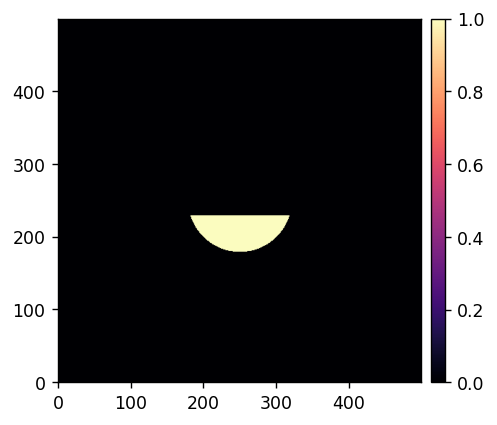

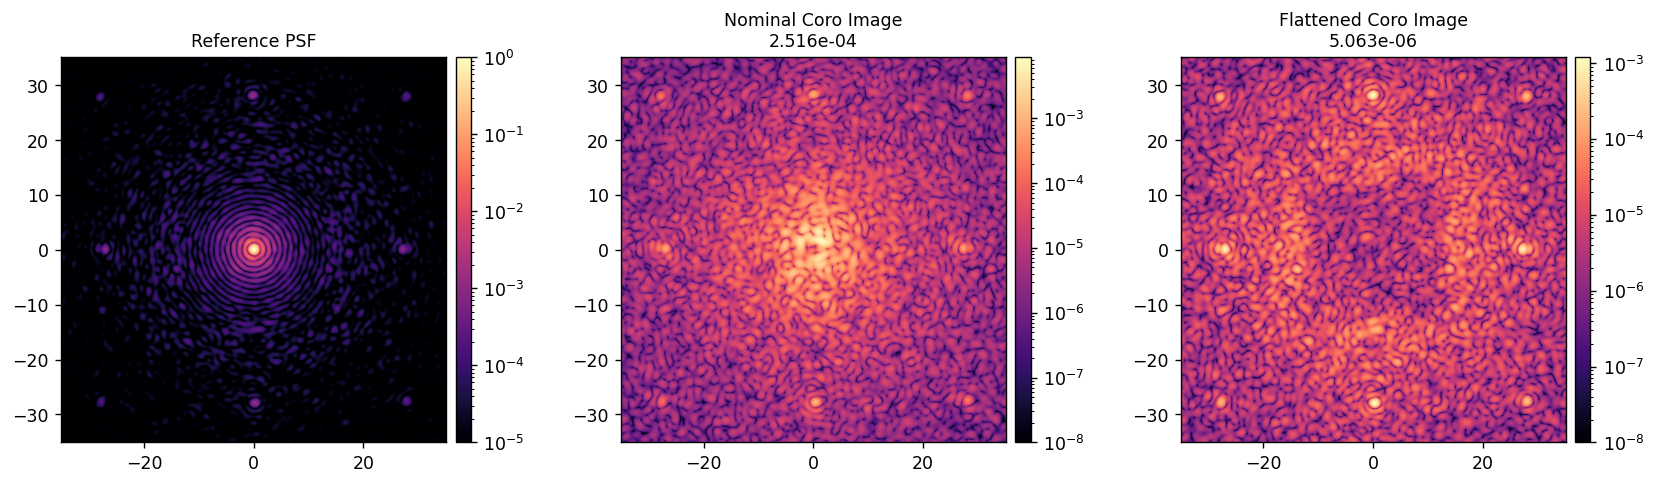

In [3]:
reload(esc)
I = esc.single(
    dm_ref=dm_flat,
)
I.wfes = wfes
I.d_collimator_exit_pupil = 203.75*u.mm
I.npsf = 500

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)

I.use_vortex = True
I.zero_dm()
coro_im_0 = I.snap()

I.reset_dm()
ref_coro_im = I.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    I.npsf,
    I.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
utils.imshow([coro_mask])

contrast_0 = utils.mean(coro_im_0, coro_mask)
ref_contrast = utils.mean(ref_coro_im, coro_mask)

utils.imshow(
    [ref_psf/I.Imax_ref, coro_im_0, ref_coro_im],
    # [ref_psf/I.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Nominal Coro Image\n{contrast_0:.3e}',
            f'Flattened Coro Image\n{ref_contrast:.3e}',],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-8)],
    pxscls=[I.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

-229.88235556450718 mm


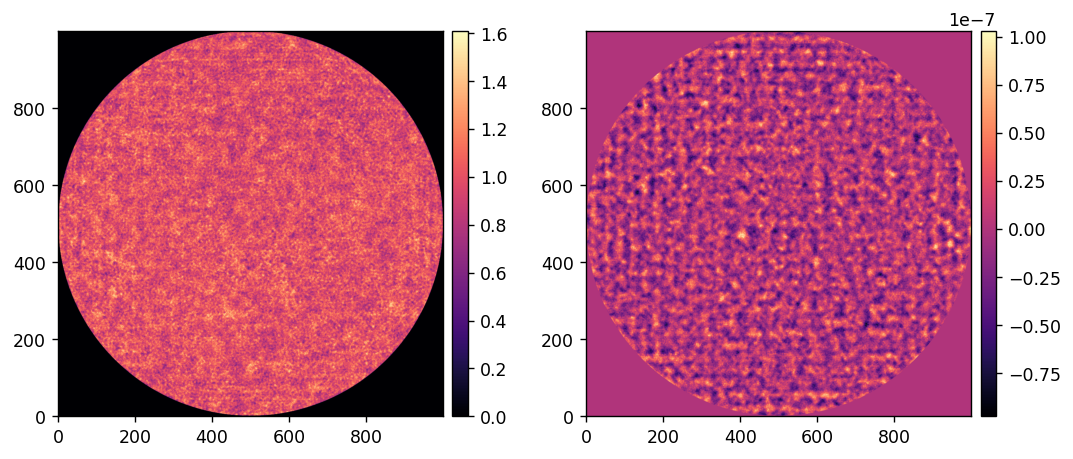

In [4]:
I.d_dm_pupil = 10.48*u.mm
# prefpm_wfe = I.calc_pupil()
prefpm_wfe = I.calc_prefpm_pupil()
prefpm_wfe = utils.pad_or_crop(prefpm_wfe, I.npix)
prefpm_amp = xp.abs(prefpm_wfe) * I.GAP_MASK
prefpm_phs = xp.angle(prefpm_wfe) * I.GAP_MASK
prefpm_opd = I.wavelength_c.to_value(u.m) / (2*xp.pi) * prefpm_phs

utils.imshow([prefpm_amp, prefpm_opd])

In [5]:
d_exit_pupil_filter = esc_optics.distances['collimator-filter'] - I.d_collimator_exit_pupil
d_filter_final_oap = esc_optics.distances['filter-output_qwp'] + esc_optics.distances['output_qwp-output_lp'] + esc_optics.distances['output_lp-oap10']
# d_exit_pupil_filter, d_filter_final_oap

d_exit_pupil_final_oap = d_exit_pupil_filter + d_filter_final_oap
d_exit_pupil_final_oap_FFP = d_exit_pupil_final_oap - esc_optics.apparent_fls['oap10']
print(d_exit_pupil_final_oap, d_exit_pupil_final_oap_FFP)

model_exit_pupil_prop_distance = (I.lyot_pupil_diam/I.final_pupil_diam)**2 * d_exit_pupil_final_oap_FFP
# model_exit_pupil_prop_distance = 1/(I.lyot_pupil_diam/I.final_pupil_diam)**2 * d_exit_pupil_final_oap_FFP
print(model_exit_pupil_prop_distance)

365.05786422437086 mm 218.47842979531555 mm
236.33907683093548 mm


Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


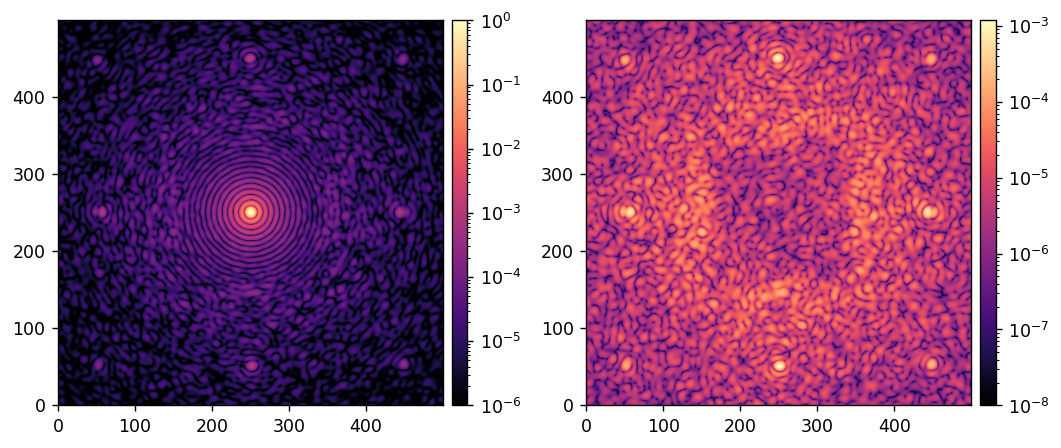

In [16]:
reload(esc_cm)

M = esc_cm.MODEL()
M.psf_pixelscale_lamDc = I.camsci_pxscl_lamDc
M.npsf = 500
M.exit_pupil_prop_distance = model_exit_pupil_prop_distance.to_value(u.m) + 1.0e-3
M.exit_pupil_prop_distance = model_exit_pupil_prop_distance.to_value(u.m) - 1.5e-3

M.AMP = copy.copy(prefpm_amp)
M.OPD = copy.copy(prefpm_opd)

# M.reverse_lyot = True

model_psf = xp.abs(M.forward(xp.zeros(M.Nacts), use_vortex=0))**2
M.Imax_ref = xp.max(model_psf)
model_psf /= M.Imax_ref

model_coro_im = xp.abs(M.forward(xp.zeros(M.Nacts), fancy_plot=0))**2

utils.imshow(
    [model_psf, model_coro_im],
    norms=[LogNorm(1e-6), LogNorm(1e-8)],
)

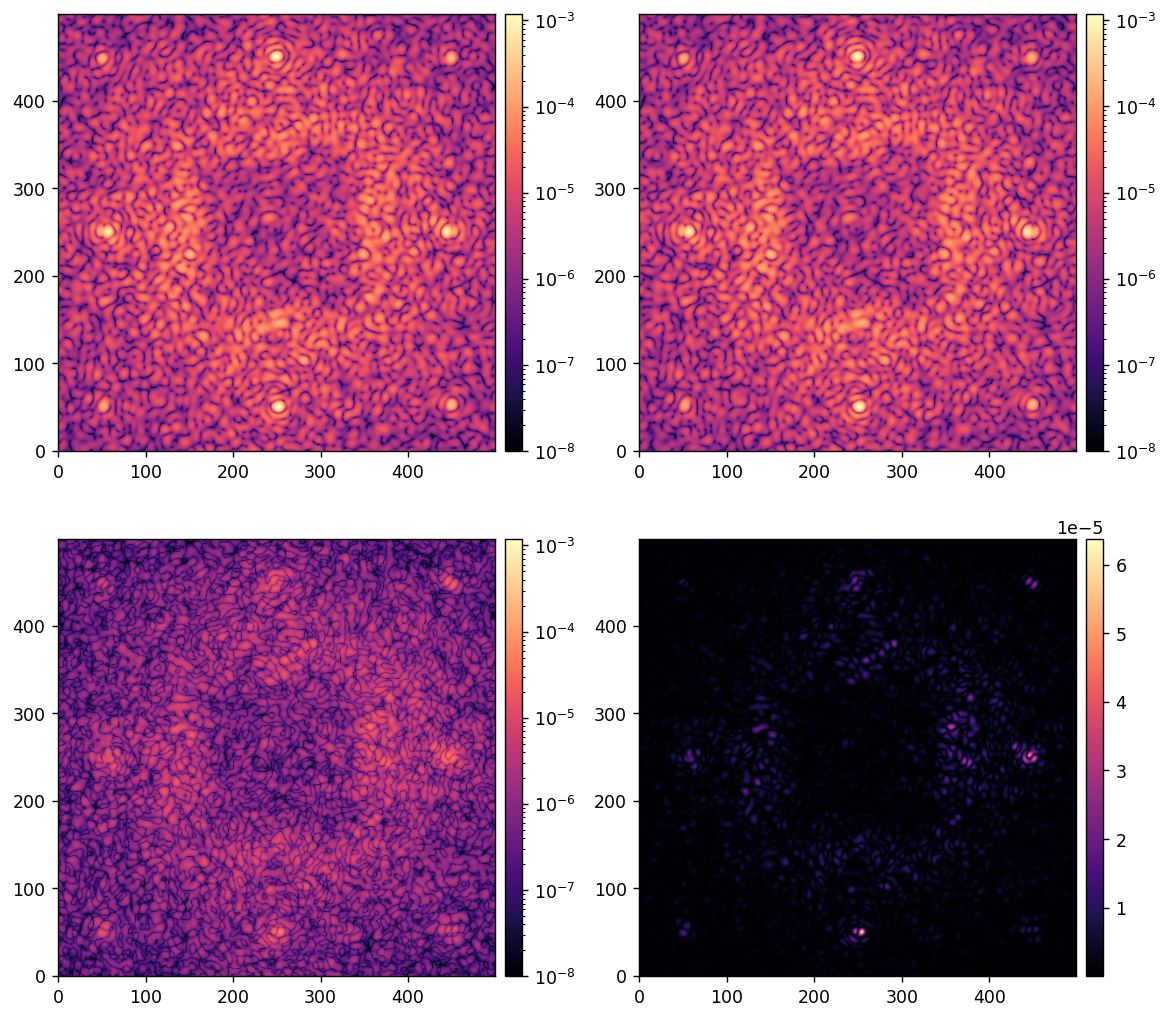

In [7]:
diff = xp.abs(ref_coro_im - model_coro_im)
utils.imshow(
    [ref_coro_im, model_coro_im, diff, diff],
    norms=[LogNorm(1e-8), LogNorm(1e-8), LogNorm(1e-8, xp.max(ref_coro_im)), None, ],
    Nrows=2, Ncols=2,
    figsize=(11,10),
)

In [17]:
reload(aefc)
I.reset_dm()
I.use_vortex = 1
data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'efields':[],
    'commands':[],
    'del_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':M.psf_pixelscale_lamDc,
    'control_mask':coro_mask, 
}

Running iteration 1


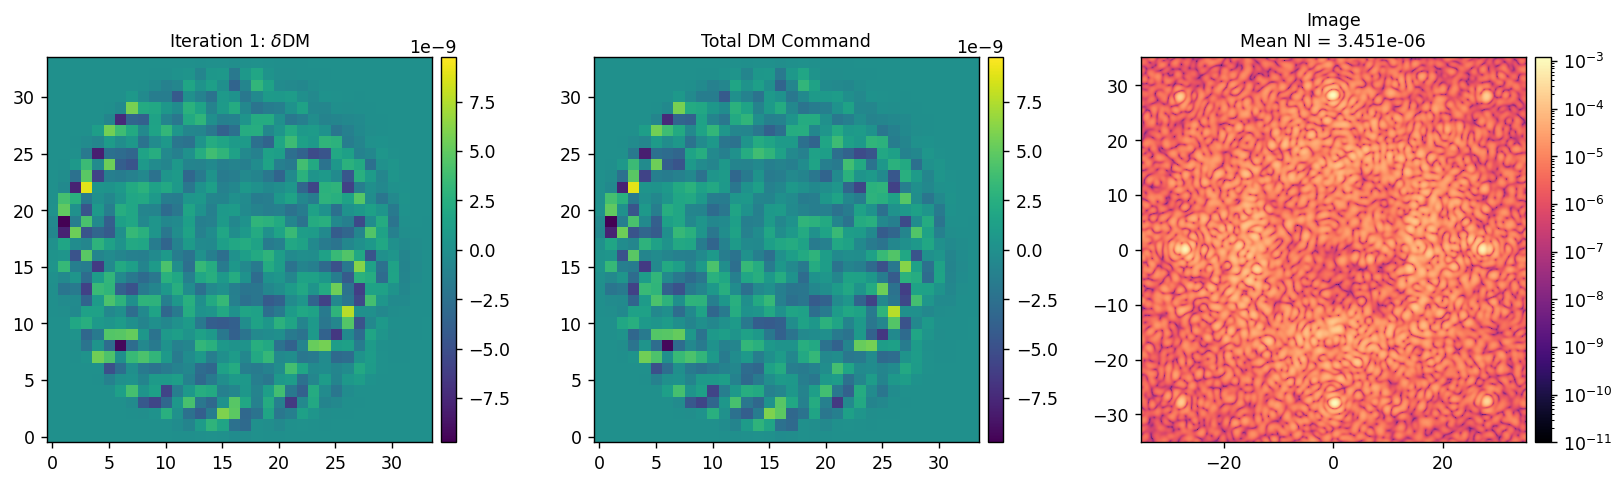

Running iteration 2


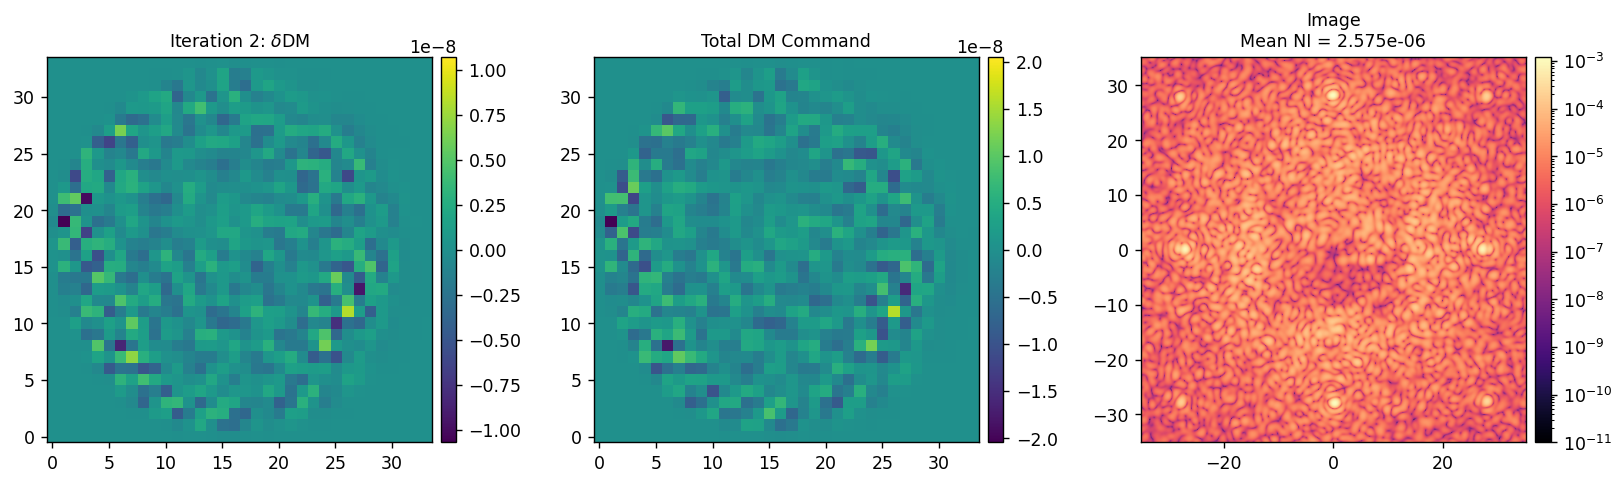

Running iteration 3


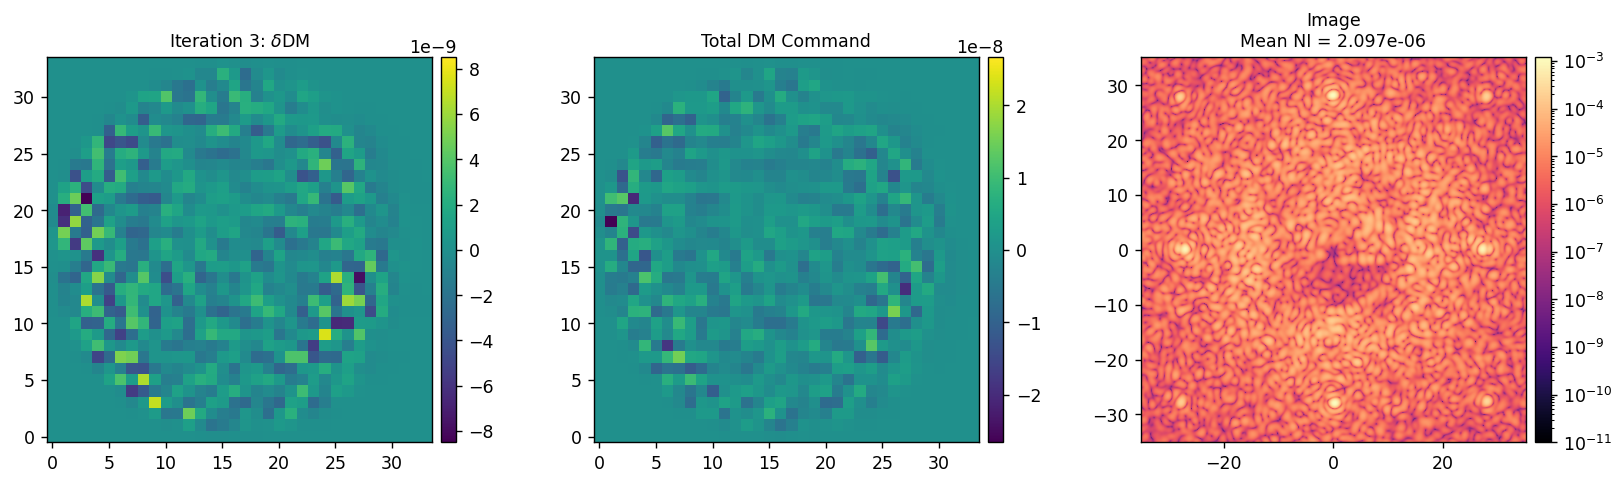

In [18]:
reload(esc_cm)
reload(aefc)
reload(utils)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5

bfgs_opts = {
    'disp':1,
    'maxiter':50,
    'maxls':10,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run(
    I, 
    M, 
    esc_cm.val_and_grad, 
    coro_mask, 
    data,
    # Nitr=3, reg_cond=1e-2,
    Nitr=3, reg_cond=1e-3,
    # Nitr=2, reg_cond=1e-6,
    # Nitr=2, reg_cond=1e-7,
    # Nitr=2, reg_cond=1e-8,
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
    vmin=1e-11,
)